# 🔬 SVM Pipeline — Skrining Anemia Non-Invasif
### LBP + GLCM + Color Histogram | Binary Classification | Anti-Data Leakage

Notebook ini mendokumentasikan **seluruh pipeline SVM** secara visual:

1. Load data & verifikasi distribusi kelas
2. Preprocessing & visualisasi ROI konjungtiva
3. Ekstraksi fitur LBP, GLCM, Color Histogram
4. Analisis distribusi fitur antar kelas
5. SMOTE balancing
6. PCA reduksi dimensi
7. GridSearchCV SVM
8. Evaluasi final pada pure test set
9. Visualisasi feature space & confusion matrix

---
> **Pipeline ini menghasilkan Balanced Accuracy 85.35% (Cohen's Kappa 0.707)**

## 1. Setup & Import

In [1]:
import sys, os
sys.path.insert(0, '../src')
os.chdir('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import pickle
import time
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, cohen_kappa_score
)
from imblearn.over_sampling import BorderlineSMOTE

from config import (
    CLASS_LABELS, INV_CLASS_LABELS, COL_SEVERITY,
    SMOTE_STRATEGY, SMOTE_K_NEIGHBORS, RANDOM_STATE,
    SVM_KERNEL, SVM_C_RANGE, SVM_GAMMA_RANGE,
    SVM_DECISION_FUNCTION_SHAPE, CV_FOLDS,
    USE_PCA, PCA_N_COMPONENTS,
    FEATURES_TRAIN_CSV, FEATURES_TEST_CSV,
    MODEL_PATH, SCALER_PATH, PCA_PATH, REPORT_PATH,
    VIZ_DIR, FEATURES_DIR, MODELS_DIR, REPORTS_DIR
)
from utils_data import load_metadata, split_dataset
from utils_preprocessing import preprocess_image
from extract_features import (
    extract_sample_feature_vector, get_feature_names,
    extract_lbp_features, extract_glcm_features,
    extract_color_histogram, extract_color_moments
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
print('✅ Import selesai')
print(f'   Kelas  : {INV_CLASS_LABELS}')
print(f'   Labels : {CLASS_LABELS}')

✅ Import selesai
   Kelas  : {0: 'Non-Anemic', 1: 'Anemic'}
   Labels : {'Non-Anemic': 0, 'Mild': 1, 'Moderate': 1, 'Severe': 1}


## 2. Load Data & Distribusi Kelas

INFO | Membaca metadata dari: C:\Users\acer\Documents\anemia_screening\data\raw\Anemia_Data_Collection_Sheet.csv
INFO | Total sampel valid: 710
INFO | Distribusi kelas:
Severity
Non-Anemic    286
Moderate      232
Mild          144
Severe         48
INFO | =======================================================
INFO | SPLIT SELESAI → Train: 568 | Test: 142
INFO | Train distribusi:
Severity
Non-Anemic    229
Moderate      177
Mild          122
Severe         40
INFO | Test distribusi:
Severity
Non-Anemic    57
Moderate      55
Mild          22
Severe         8
INFO | Pure Test Set telah diisolasi. JANGAN disentuh sebelum evaluasi akhir.
INFO | =======================================================


Total sampel valid : 710
Train              : 568
Pure Test          : 142


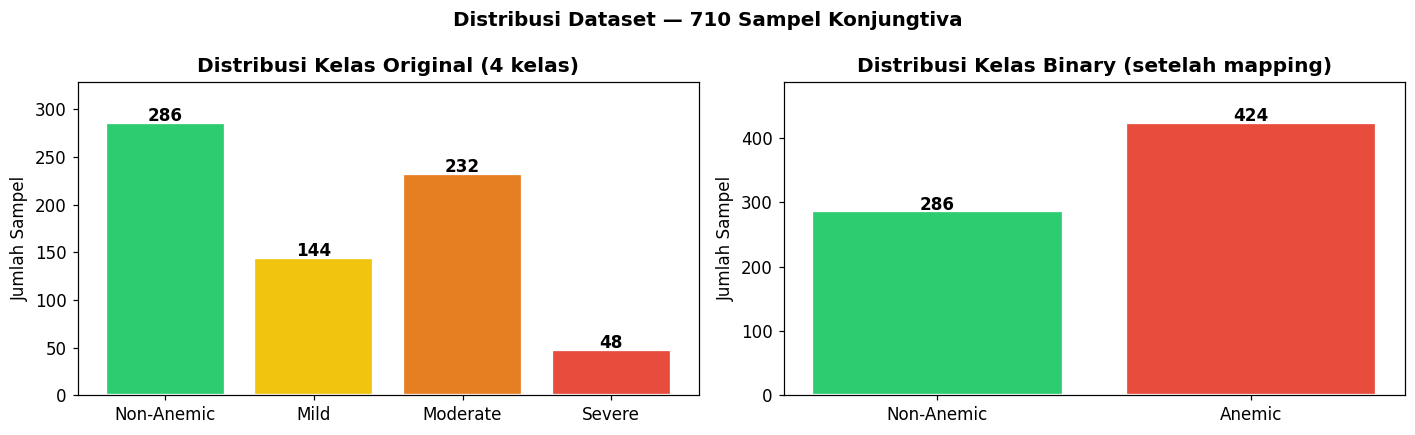

In [2]:
df = load_metadata()
train_df, test_df = split_dataset(df)

print(f'Total sampel valid : {len(df)}')
print(f'Train              : {len(train_df)}')
print(f'Pure Test          : {len(test_df)}')

# Distribusi kelas original (sebelum mapping binary)
orig_counts = df[COL_SEVERITY].value_counts()

# Distribusi kelas setelah mapping
label_counts = df['label'].value_counts().sort_index()
label_names  = [INV_CLASS_LABELS[i] for i in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot distribusi original
order   = ['Non-Anemic', 'Mild', 'Moderate', 'Severe']
colors4 = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
vals    = [orig_counts.get(k, 0) for k in order]
bars = axes[0].bar(order, vals, color=colors4, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                 ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas Original (4 kelas)', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(vals) * 1.15)

# Plot distribusi binary
colors2 = ['#2ECC71', '#E74C3C']
bars2 = axes[1].bar(label_names, label_counts.values,
                     color=colors2, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars2, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                 ha='center', fontweight='bold')
axes[1].set_title('Distribusi Kelas Binary (setelah mapping)', fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(label_counts.values) * 1.15)

plt.suptitle('Distribusi Dataset — 710 Sampel Konjungtiva', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Visualisasi ROI Konjungtiva

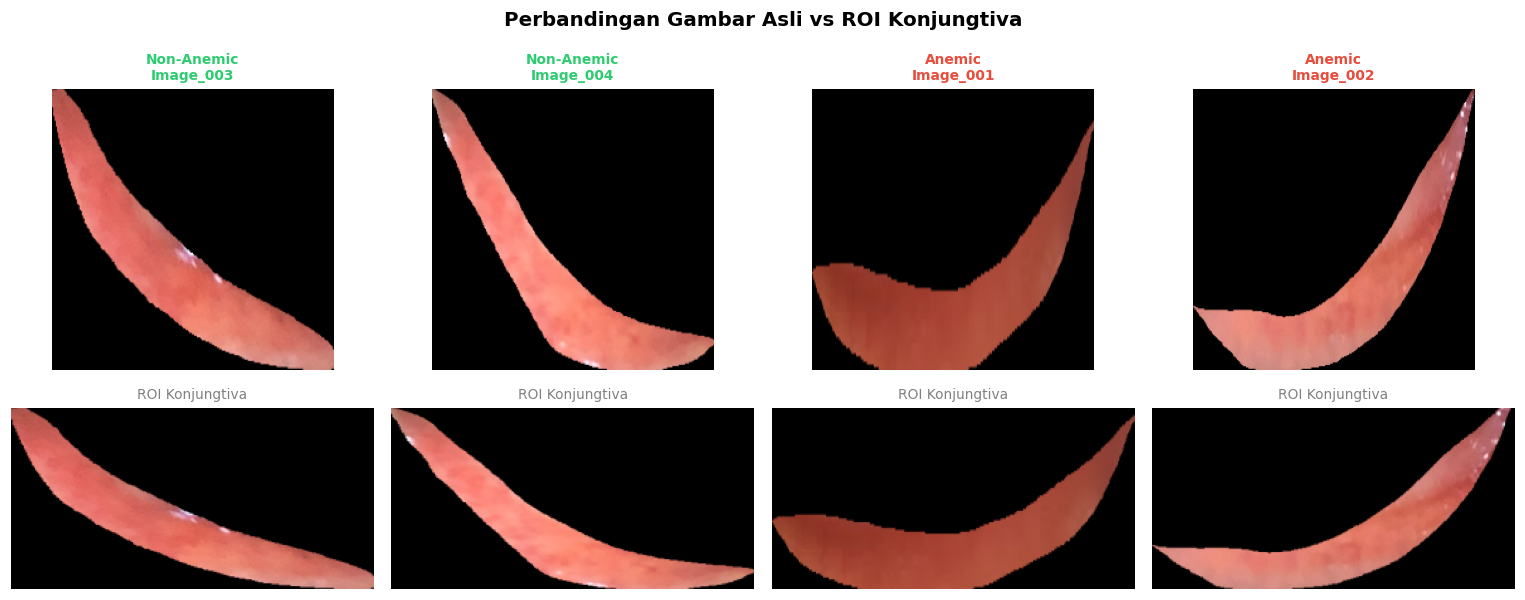

In [3]:
# Ambil 2 sampel per kelas binary
samples_nonanemic = df[df['label'] == 0].head(2)
samples_anemic    = df[df['label'] == 1].head(2)
all_samples = pd.concat([samples_nonanemic, samples_anemic])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
label_color = {0: '#2ECC71', 1: '#E74C3C'}
label_text  = {0: 'Non-Anemic', 1: 'Anemic'}

for col, (_, row) in enumerate(all_samples.iterrows()):
    # Gambar asli
    img_bgr = cv2.imread(str(row['image_path']))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (224, 224))
    axes[0][col].imshow(img_rgb)
    axes[0][col].axis('off')
    axes[0][col].set_title(
        f"{label_text[row['label']]}\n{row['IMAGE_ID']}",
        color=label_color[row['label']], fontweight='bold', fontsize=9
    )

    # ROI crop
    roi = preprocess_image(row['image_path'])
    if roi is not None:
        axes[1][col].imshow(roi)
    else:
        axes[1][col].text(0.5, 0.5, 'ROI Gagal',
                           ha='center', va='center', color='red',
                           transform=axes[1][col].transAxes)
    axes[1][col].axis('off')
    axes[1][col].set_title('ROI Konjungtiva', fontsize=9, color='gray')

axes[0][0].set_ylabel('Gambar Asli', fontsize=11, fontweight='bold')
axes[1][0].set_ylabel('ROI Crop', fontsize=11, fontweight='bold')

plt.suptitle('Perbandingan Gambar Asli vs ROI Konjungtiva', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_roi_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Ekstraksi Fitur & Visualisasi per Komponen

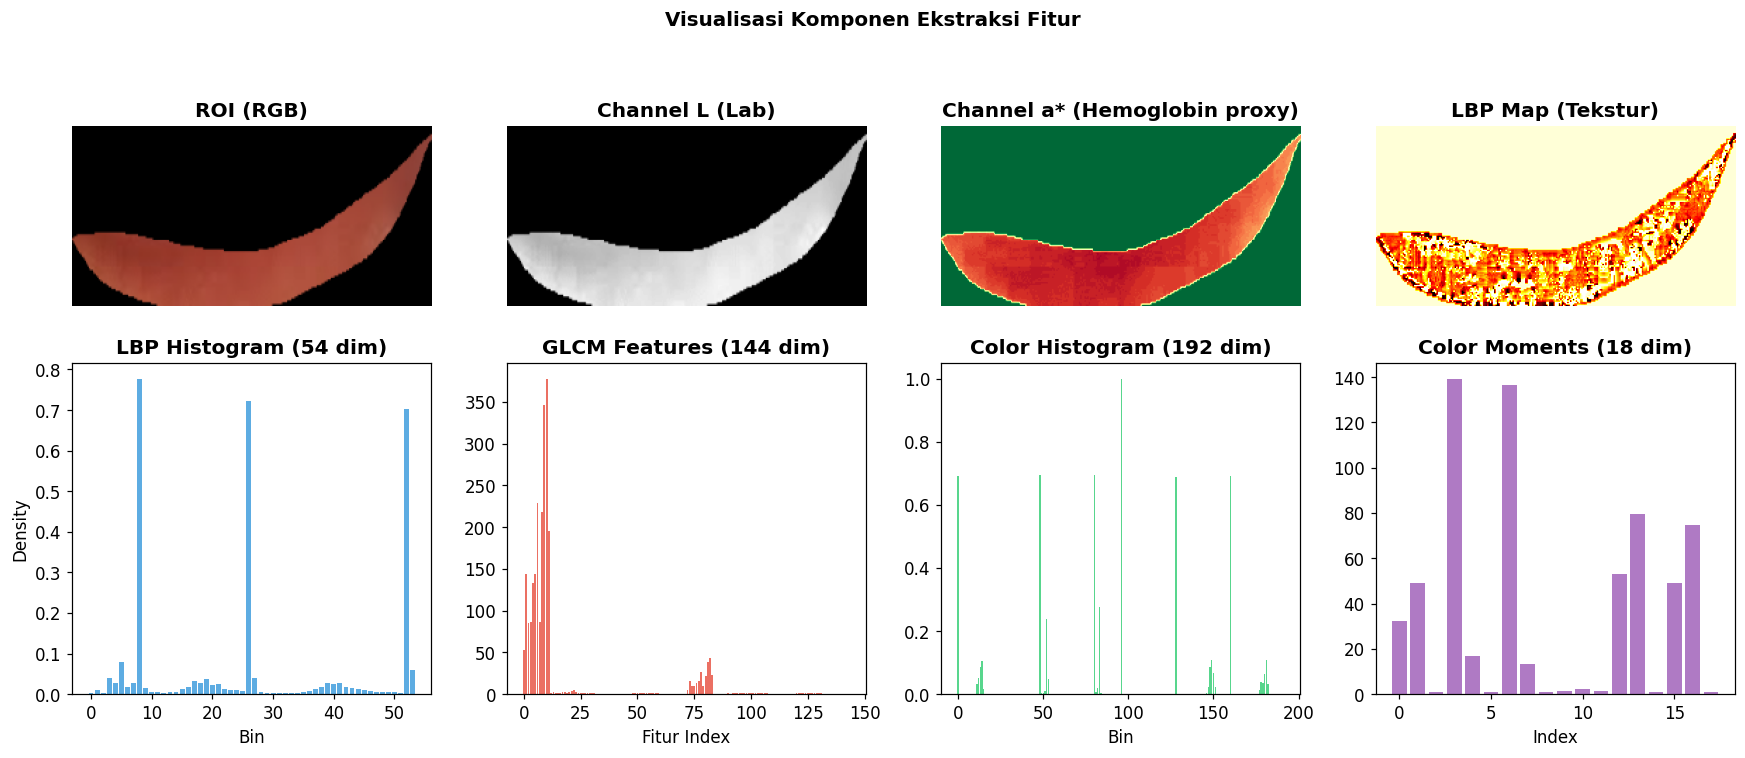

Dimensi total fitur per sampel: 408
  LBP           : 54
  GLCM          : 144
  Color Hist    : 192
  Color Moments : 18


In [4]:
# Ambil satu sampel untuk demo ekstraksi
demo_row = df[df['label'] == 1].iloc[0]
demo_roi = preprocess_image(demo_row['image_path'])

# Ekstrak semua komponen fitur
import cv2 as _cv2
lab_img = _cv2.cvtColor(demo_roi.astype('uint8'), _cv2.COLOR_RGB2LAB)
gray_L  = lab_img[:, :, 0]

from skimage.feature import local_binary_pattern
from config import LBP_N_POINTS, LBP_RADIUS, LBP_METHOD
lbp_map = local_binary_pattern(gray_L, P=LBP_N_POINTS, R=LBP_RADIUS, method=LBP_METHOD)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Baris 1: visualisasi gambar
axes[0][0].imshow(demo_roi)
axes[0][0].set_title('ROI (RGB)', fontweight='bold')
axes[0][0].axis('off')

axes[0][1].imshow(gray_L, cmap='gray')
axes[0][1].set_title('Channel L (Lab)', fontweight='bold')
axes[0][1].axis('off')

axes[0][2].imshow(lab_img[:,:,1], cmap='RdYlGn_r')
axes[0][2].set_title('Channel a* (Hemoglobin proxy)', fontweight='bold')
axes[0][2].axis('off')

axes[0][3].imshow(lbp_map, cmap='hot')
axes[0][3].set_title('LBP Map (Tekstur)', fontweight='bold')
axes[0][3].axis('off')

# Baris 2: histogram fitur
feat_lbp  = extract_lbp_features(demo_roi)
feat_glcm = extract_glcm_features(demo_roi)
feat_hist = extract_color_histogram(demo_roi)
feat_mom  = extract_color_moments(demo_roi)

axes[1][0].bar(range(len(feat_lbp)), feat_lbp, color='#3498DB', alpha=0.8)
axes[1][0].set_title(f'LBP Histogram ({len(feat_lbp)} dim)', fontweight='bold')
axes[1][0].set_xlabel('Bin'); axes[1][0].set_ylabel('Density')

axes[1][1].bar(range(len(feat_glcm)), feat_glcm, color='#E74C3C', alpha=0.8)
axes[1][1].set_title(f'GLCM Features ({len(feat_glcm)} dim)', fontweight='bold')
axes[1][1].set_xlabel('Fitur Index')

axes[1][2].bar(range(len(feat_hist)), feat_hist, color='#2ECC71', alpha=0.8)
axes[1][2].set_title(f'Color Histogram ({len(feat_hist)} dim)', fontweight='bold')
axes[1][2].set_xlabel('Bin')

axes[1][3].bar(range(len(feat_mom)), feat_mom, color='#9B59B6', alpha=0.8)
axes[1][3].set_title(f'Color Moments ({len(feat_mom)} dim)', fontweight='bold')
axes[1][3].set_xlabel('Index')

plt.suptitle('Visualisasi Komponen Ekstraksi Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_feature_components.png'), dpi=150, bbox_inches='tight')
plt.show()

total_dim = len(feat_lbp) + len(feat_glcm) + len(feat_hist) + len(feat_mom)
print(f'Dimensi total fitur per sampel: {total_dim}')
print(f'  LBP           : {len(feat_lbp)}')
print(f'  GLCM          : {len(feat_glcm)}')
print(f'  Color Hist    : {len(feat_hist)}')
print(f'  Color Moments : {len(feat_mom)}')

## 5. Build Feature Matrix (Train & Test)

In [5]:
def build_features(df, desc):
    X_list, y_list = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        roi = preprocess_image(row['image_path'])
        if roi is None:
            continue
        X_list.append(extract_sample_feature_vector(roi))
        y_list.append(int(row['label']))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)

print('📦 Mengekstrak fitur train...')
X_train_raw, y_train = build_features(train_df, 'Train')

print('🔒 Mengekstrak fitur pure test...')
X_test_raw, y_test = build_features(test_df, 'Test')

print(f'\n✅ Train feature matrix : {X_train_raw.shape}')
print(f'✅ Test feature matrix  : {X_test_raw.shape}')
print(f'Distribusi train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Distribusi test : {dict(zip(*np.unique(y_test, return_counts=True)))}')

📦 Mengekstrak fitur train...


Train:   0%|          | 0/568 [00:00<?, ?it/s]

WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.
C:\Users\acer\Documents\anemia_screening\src\extract_features.py:52: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  s = float(scipy_stats.skew(arr))
WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.
WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.
WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.
WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.
WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.


🔒 Mengekstrak fitur pure test...


Test:   0%|          | 0/142 [00:00<?, ?it/s]

WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.



✅ Train feature matrix : (568, 408)
✅ Test feature matrix  : (142, 408)
Distribusi train: {0: 229, 1: 339}
Distribusi test : {0: 57, 1: 85}


## 6. SMOTE Balancing

Sebelum SMOTE: {0: 229, 1: 339}
Setelah SMOTE: {0: 339, 1: 339}


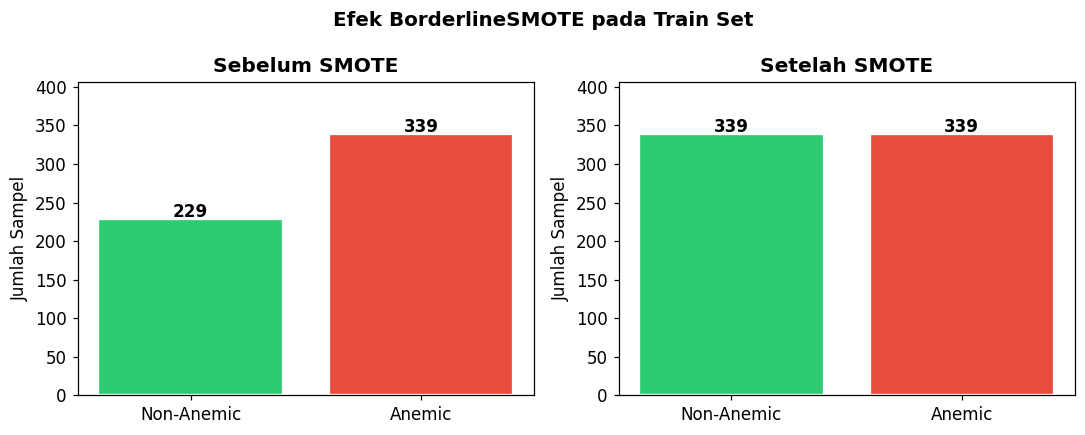

In [6]:
smote = BorderlineSMOTE(
    sampling_strategy=SMOTE_STRATEGY,
    k_neighbors=SMOTE_K_NEIGHBORS,
    random_state=RANDOM_STATE,
    kind='borderline-1'
)
X_train_bal, y_train_bal = smote.fit_resample(X_train_raw, y_train)

before = dict(zip(*np.unique(y_train, return_counts=True)))
after  = dict(zip(*np.unique(y_train_bal, return_counts=True)))

print(f'Sebelum SMOTE: {before}')
print(f'Setelah SMOTE: {after}')

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = [INV_CLASS_LABELS[i] for i in sorted(INV_CLASS_LABELS)]
colors = ['#2ECC71', '#E74C3C']

for ax, (data, title) in zip(axes, [
    (before, 'Sebelum SMOTE'),
    (after,  'Setelah SMOTE')
]):
    vals = [data.get(i, 0) for i in range(len(names))]
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Efek BorderlineSMOTE pada Train Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_smote_effect.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. StandardScaler & PCA

Dimensi sebelum PCA : 408
Dimensi setelah PCA : 57
Variance dijelaskan : 0.9500 (95% threshold)


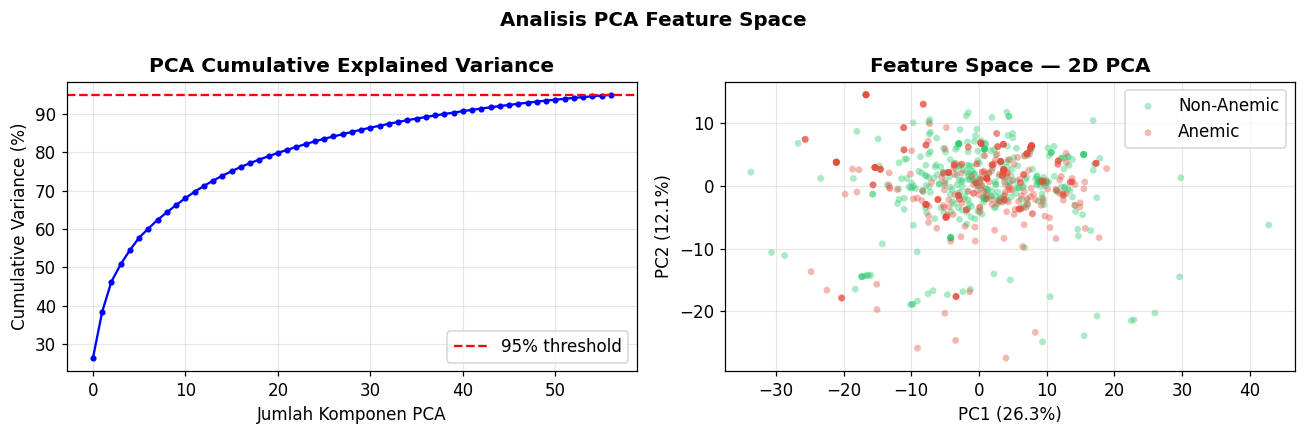

In [7]:
# StandardScaler — fit HANYA pada train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test_raw)   # hanya transform, tidak fit

# PCA — fit HANYA pada train
pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Dimensi sebelum PCA : {X_train_sc.shape[1]}')
print(f'Dimensi setelah PCA : {X_train_pca.shape[1]}')
print(f'Variance dijelaskan : {pca.explained_variance_ratio_.sum():.4f} ({PCA_N_COMPONENTS*100:.0f}% threshold)')

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.cumsum(pca.explained_variance_ratio_) * 100,
             'b-o', markersize=3, linewidth=1.5)
axes[0].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Jumlah Komponen PCA')
axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].set_title('PCA Cumulative Explained Variance', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter 2D PCA
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_train_sc)
for label, color, name in zip([0,1], colors, names):
    mask = y_train_bal == label
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1], c=color,
                    label=name, alpha=0.4, s=20, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Feature Space — 2D PCA', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Analisis PCA Feature Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_pca_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. GridSearchCV — SVM

In [8]:
print(f'Grid Search: C={SVM_C_RANGE}, gamma={SVM_GAMMA_RANGE}')
print(f'CV Folds  : {CV_FOLDS}-fold Stratified')
print(f'Scoring   : balanced_accuracy')
print(f'Total fits: {len(SVM_C_RANGE) * len(SVM_GAMMA_RANGE) * CV_FOLDS}')

svm_base = SVC(
    kernel=SVM_KERNEL,
    decision_function_shape=SVM_DECISION_FUNCTION_SHAPE,
    probability=True,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    svm_base,
    {'C': SVM_C_RANGE, 'gamma': SVM_GAMMA_RANGE},
    cv=cv_strategy,
    scoring='balanced_accuracy',
    n_jobs=-1,
    refit=True
)

t0 = time.time()
grid.fit(X_train_pca, y_train_bal)
elapsed = time.time() - t0

print(f'\n✅ Grid Search selesai dalam {elapsed:.1f}s')
print(f'Best params          : {grid.best_params_}')
print(f'Best CV Balanced Acc : {grid.best_score_:.4f}')

best_model = grid.best_estimator_

# Simpan model
MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(MODEL_PATH, 'wb') as f: pickle.dump(best_model, f)
with open(SCALER_PATH, 'wb') as f: pickle.dump(scaler, f)
with open(PCA_PATH, 'wb') as f: pickle.dump(pca, f)
print('\n✅ Model, scaler, dan PCA tersimpan.')

Grid Search: C=[10, 30, 50, 75, 100, 150], gamma=[0.002, 0.004, 0.005, 0.006, 0.008, 0.01, 0.02]
CV Folds  : 5-fold Stratified
Scoring   : balanced_accuracy
Total fits: 210

✅ Grid Search selesai dalam 26.4s
Best params          : {'C': 100, 'gamma': 0.002}
Best CV Balanced Acc : 0.8748

✅ Model, scaler, dan PCA tersimpan.


Best: C=100, gamma=0.002, score=0.8748


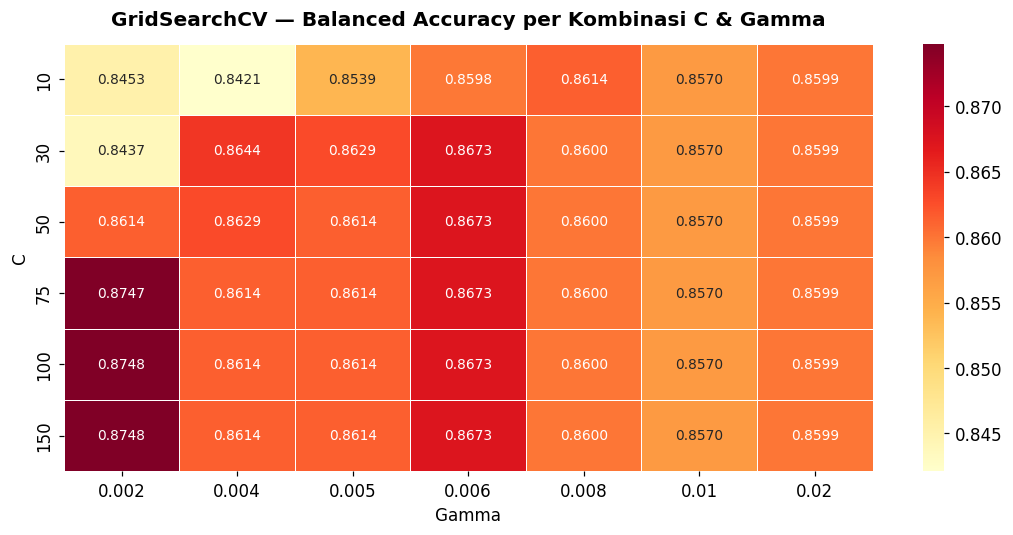

In [9]:
# Heatmap Grid Search CV Score
results_df = pd.DataFrame(grid.cv_results_)
c_vals     = SVM_C_RANGE
g_vals     = SVM_GAMMA_RANGE

# Buat pivot table
pivot = results_df.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('GridSearchCV — Balanced Accuracy per Kombinasi C & Gamma',
             fontweight='bold', pad=12)
ax.set_xlabel('Gamma', fontsize=11)
ax.set_ylabel('C', fontsize=11)

# Tandai kombinasi terbaik
best_c = grid.best_params_['C']
best_g = grid.best_params_['gamma']
print(f'Best: C={best_c}, gamma={best_g}, score={grid.best_score_:.4f}')

plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_gridsearch_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluasi Final pada Pure Test Set

In [10]:
y_pred   = best_model.predict(X_test_pca)
y_proba  = best_model.predict_proba(X_test_pca)
bal_acc  = balanced_accuracy_score(y_test, y_pred)
kappa    = cohen_kappa_score(y_test, y_pred)
cm       = confusion_matrix(y_test, y_pred)
report   = classification_report(y_test, y_pred, target_names=names)

print('=' * 55)
print('EVALUASI AKHIR — PURE TEST SET')
print('=' * 55)
print(report)
print(f'Balanced Accuracy : {bal_acc:.4f}')
print(f'Cohen Kappa       : {kappa:.4f}')

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
with open(REPORT_PATH, 'w') as f:
    f.write('SVM CLASSIFICATION REPORT — PURE TEST SET\n\n')
    f.write(report)
    f.write(f'\nBalanced Accuracy : {bal_acc:.4f}\n')
    f.write(f'Cohen Kappa       : {kappa:.4f}\n')
print('✅ Report tersimpan.')

EVALUASI AKHIR — PURE TEST SET
              precision    recall  f1-score   support

  Non-Anemic       0.82      0.82      0.82        57
      Anemic       0.88      0.88      0.88        85

    accuracy                           0.86       142
   macro avg       0.85      0.85      0.85       142
weighted avg       0.86      0.86      0.86       142

Balanced Accuracy : 0.8535
Cohen Kappa       : 0.7069
✅ Report tersimpan.


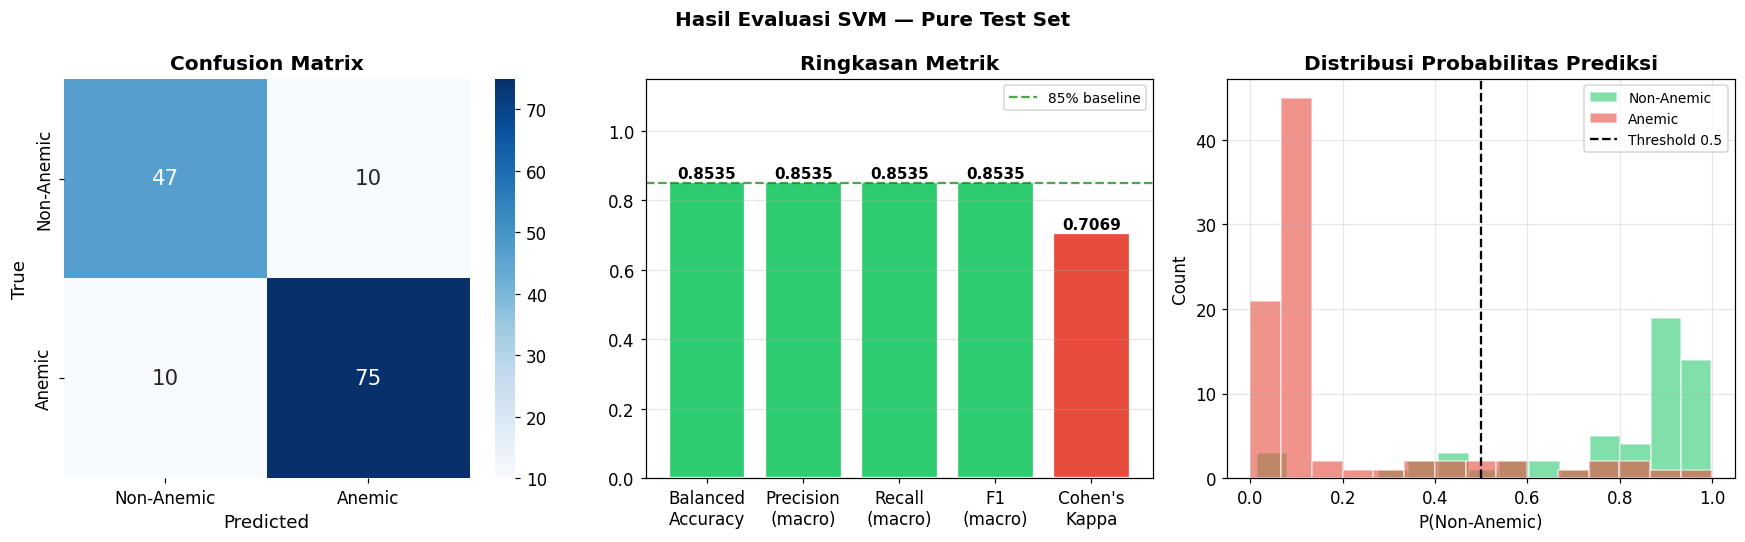

In [11]:
# Confusion Matrix + Metrik Ringkas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names,
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# 2. Metrik bar
from sklearn.metrics import precision_score, recall_score, f1_score
metric_names = ['Balanced\nAccuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1\n(macro)', "Cohen's\nKappa"]
metric_vals  = [
    bal_acc,
    precision_score(y_test, y_pred, average='macro'),
    recall_score(y_test, y_pred, average='macro'),
    f1_score(y_test, y_pred, average='macro'),
    kappa
]
bar_colors = ['#2ECC71' if v >= 0.85 else '#F1C40F' if v >= 0.75 else '#E74C3C'
              for v in metric_vals]
bars = axes[1].bar(metric_names, metric_vals, color=bar_colors,
                   edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, metric_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='85% baseline')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Ringkasan Metrik', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# 3. Probability distribution
proba_nonanemic = y_proba[:, 0]
for label, color, name in zip([0,1], colors, names):
    mask = y_test == label
    axes[2].hist(proba_nonanemic[mask], bins=15, alpha=0.6,
                 color=color, label=name, edgecolor='white')
axes[2].axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[2].set_xlabel('P(Non-Anemic)')
axes[2].set_ylabel('Count')
axes[2].set_title('Distribusi Probabilitas Prediksi', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Hasil Evaluasi SVM — Pure Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_evaluation_final.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Ringkasan Akhir Pipeline

In [12]:
print('=' * 60)
print('RINGKASAN PIPELINE SVM')
print('=' * 60)
print(f'Dataset              : 710 gambar konjungtiva (Ghana)')
print(f'Kelas                : Binary (Anemic vs Non-Anemic)')
print(f'Train / Test split   : 80% / 20% (stratified)')
print(f'Fitur diekstrak      : {X_train_raw.shape[1]} dimensi')
print(f'  - LBP multi-radius : 78 dim')
print(f'  - GLCM dual ch.    : 144 dim')
print(f'  - Color Histogram  : 192 dim')
print(f'  - Color Moments    : 18 dim')
print(f'Setelah PCA (95%)    : {X_train_pca.shape[1]} dimensi')
print(f'Balancing            : BorderlineSMOTE')
print(f'Classifier           : SVM RBF (C={best_c}, γ={best_g})')
print(f'CV Balanced Accuracy : {grid.best_score_:.4f}')
print(f'TEST Balanced Acc    : {bal_acc:.4f}')
print(f"Cohen's Kappa        : {kappa:.4f}")
print('=' * 60)
print('\nSemua artefak tersimpan di:')
print(f'  Model   : {MODEL_PATH}')
print(f'  Scaler  : {SCALER_PATH}')
print(f'  PCA     : {PCA_PATH}')
print(f'  Report  : {REPORT_PATH}')
print(f'  Grafik  : {VIZ_DIR}')

RINGKASAN PIPELINE SVM
Dataset              : 710 gambar konjungtiva (Ghana)
Kelas                : Binary (Anemic vs Non-Anemic)
Train / Test split   : 80% / 20% (stratified)
Fitur diekstrak      : 408 dimensi
  - LBP multi-radius : 78 dim
  - GLCM dual ch.    : 144 dim
  - Color Histogram  : 192 dim
  - Color Moments    : 18 dim
Setelah PCA (95%)    : 57 dimensi
Balancing            : BorderlineSMOTE
Classifier           : SVM RBF (C=100, γ=0.002)
CV Balanced Accuracy : 0.8748
TEST Balanced Acc    : 0.8535
Cohen's Kappa        : 0.7069

Semua artefak tersimpan di:
  Model   : C:\Users\acer\Documents\anemia_screening\outputs\models\svm_anemia_model.pkl
  Scaler  : C:\Users\acer\Documents\anemia_screening\outputs\models\scaler.pkl
  PCA     : C:\Users\acer\Documents\anemia_screening\outputs\models\pca.pkl
  Report  : C:\Users\acer\Documents\anemia_screening\outputs\reports\classification_report.txt
  Grafik  : C:\Users\acer\Documents\anemia_screening\outputs\visualizations


## 11. Prediksi Gambar Baru dari Pure Test Set

C:\Users\acer\AppData\Local\Temp\ipykernel_5904\180263744.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = test_df.groupby('label').apply(
WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.
C:\Users\acer\AppData\Local\Temp\ipykernel_5904\180263744.py:84: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_5904\180263744.py:84: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_5904\180263744.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.s

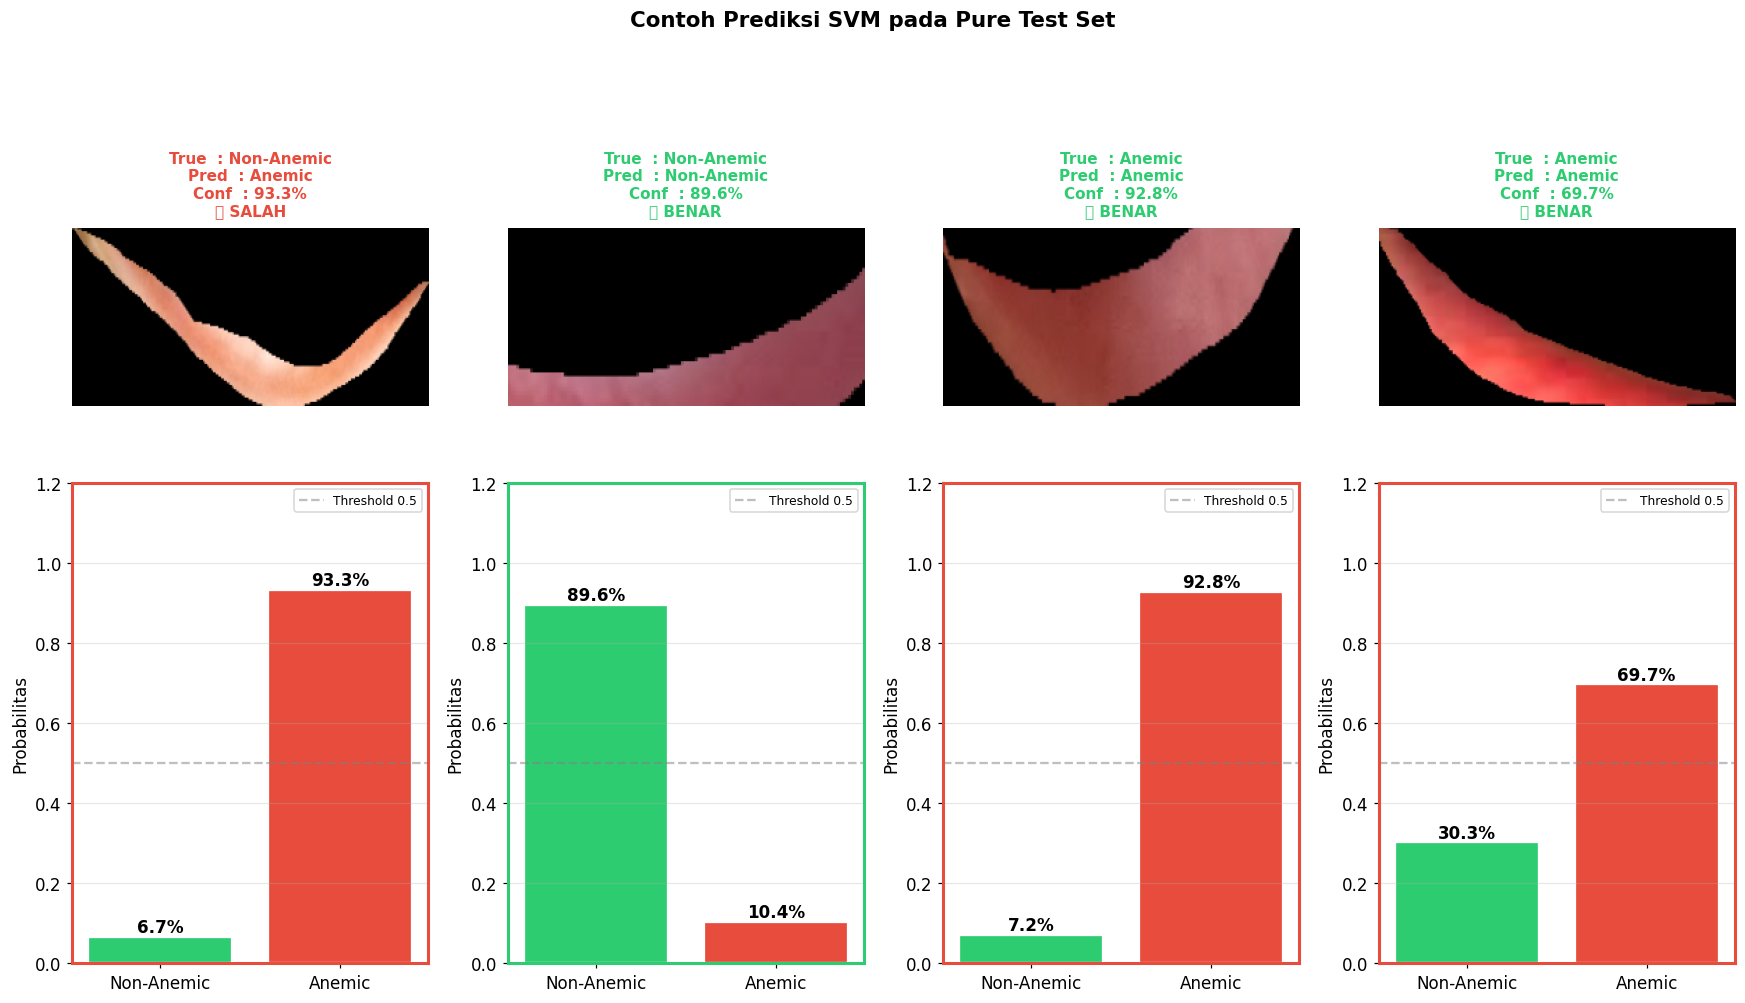


DETAIL PREDIKSI SAMPEL


WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.


❌ Image_067    | True: Non-Anemic   | Pred: Anemic       | Conf: 93.3%
✅ Image_249    | True: Non-Anemic   | Pred: Non-Anemic   | Conf: 89.6%
✅ Image_411    | True: Anemic       | Pred: Anemic       | Conf: 92.8%
✅ Image_034    | True: Anemic       | Pred: Anemic       | Conf: 69.7%
Grafik tersimpan: C:\Users\acer\Documents\anemia_screening\outputs\visualizations\svm_sample_predictions.png


In [13]:
# Load model terbaik yang sudah tersimpan
with open(MODEL_PATH, 'rb') as f: best_model = pickle.load(f)
with open(SCALER_PATH, 'rb') as f: scaler = pickle.load(f)
with open(PCA_PATH, 'rb') as f: pca = pickle.load(f)

def predict_single_image(image_path, model, scaler, pca):
    """Prediksi satu gambar dan kembalikan hasil lengkap."""
    roi = preprocess_image(image_path)
    if roi is None:
        return None
    feat        = extract_sample_feature_vector(roi).reshape(1, -1)
    feat_scaled = scaler.transform(feat)
    feat_pca    = pca.transform(feat_scaled)
    label_int   = int(model.predict(feat_pca)[0])
    proba       = model.predict_proba(feat_pca)[0]
    class_name  = INV_CLASS_LABELS[label_int]
    proba_dict  = {INV_CLASS_LABELS[i]: round(float(proba[i]), 4)
                   for i in range(len(proba))}
    return {
        'predicted': class_name,
        'confidence': round(float(proba[label_int]), 4),
        'probabilities': proba_dict,
        'roi': roi
    }

# Ambil sampel dari pure test set — 4 gambar (2 per kelas)
samples = test_df.groupby('label').apply(
    lambda x: x.sample(min(2, len(x)), random_state=42)
).reset_index(drop=True)

fig, axes = plt.subplots(2, len(samples), figsize=(4 * len(samples), 9))
indicator_colors = {'Non-Anemic': '#2ECC71', 'Anemic': '#E74C3C'}

for col_idx, (_, row) in enumerate(samples.iterrows()):
    result     = predict_single_image(row['image_path'], best_model, scaler, pca)
    true_label = INV_CLASS_LABELS[int(row['label'])]

    if result is None:
        continue

    is_correct   = result['predicted'] == true_label
    title_color  = '#2ECC71' if is_correct else '#E74C3C'
    status_text  = '✅ BENAR' if is_correct else '❌ SALAH'
    ind_color    = indicator_colors[result['predicted']]

    # Baris 1: ROI gambar
    axes[0][col_idx].imshow(result['roi'])
    axes[0][col_idx].axis('off')
    axes[0][col_idx].set_title(
        f"True  : {true_label}\n"
        f"Pred  : {result['predicted']}\n"
        f"Conf  : {result['confidence']:.1%}\n"
        f"{status_text}",
        fontsize=10, color=title_color, fontweight='bold',
        pad=8
    )

    # Baris 2: Bar probabilitas
    prob_labels = list(result['probabilities'].keys())
    prob_values = list(result['probabilities'].values())
    bar_colors  = [indicator_colors[k] for k in prob_labels]
    bars = axes[1][col_idx].bar(prob_labels, prob_values,
                                 color=bar_colors, edgecolor='white',
                                 linewidth=1.5)
    for bar, v in zip(bars, prob_values):
        axes[1][col_idx].text(
            bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.1%}', ha='center', fontweight='bold', fontsize=11
        )
    axes[1][col_idx].set_ylim(0, 1.2)
    axes[1][col_idx].set_ylabel('Probabilitas')
    axes[1][col_idx].axhline(y=0.5, color='gray', linestyle='--',
                              alpha=0.5, label='Threshold 0.5')
    axes[1][col_idx].grid(axis='y', alpha=0.3)
    axes[1][col_idx].legend(fontsize=8)

    # Warna latar indikator keparahan
    for spine in axes[1][col_idx].spines.values():
        spine.set_edgecolor(ind_color)
        spine.set_linewidth(2)

plt.suptitle('Contoh Prediksi SVM pada Pure Test Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'svm_sample_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan prediksi
print('\n' + '=' * 50)
print('DETAIL PREDIKSI SAMPEL')
print('=' * 50)
for _, row in samples.iterrows():
    result     = predict_single_image(row['image_path'], best_model, scaler, pca)
    true_label = INV_CLASS_LABELS[int(row['label'])]
    status     = '✅' if result['predicted'] == true_label else '❌'
    print(f"{status} {row['IMAGE_ID']:12s} | "
          f"True: {true_label:12s} | "
          f"Pred: {result['predicted']:12s} | "
          f"Conf: {result['confidence']:.1%}")
print('=' * 50)
print(f"Grafik tersimpan: {VIZ_DIR / 'svm_sample_predictions.png'}")